**Problem Statement**

**Retail supermarket** chains operate across hundreds of stores and sell thousands of product families, each with distinct demand patterns driven by seasonality, promotions, holidays, wages cycles, and macroeconomic shocks (e.g., oil prices in an oil-dependent economy). Inaccurate sales forecasts lead to two costly outcomes: overstocking, which ties up capital and increases spoilage/waste for perishable goods, and stockouts, which cause lost sales and poor customer experience.

**Dataset**
The project contains multiple datasets such as historical sales, product information, store
information, holidays, transactions, external indicators, and a prediction dataset.

**Dataset Description**
In this competition, we will predict sales for the thousands of product families sold at
Favorita stores located in Ecuador. The training data includes dates, store and product
information, whether that item was being promoted, as well as the sales numbers. Additional
files include supplementary information that may be useful in building your models.

Corporación Favorita, a large Ecuadorian grocery retailer, needs a data-driven forecasting solution that predicts daily unit sales for each product family at each store, 15 days into the future. The historical data spans multiple stores, product families, and several years of daily transactions, and is influenced by irregular factors such as:

**Promotions** — items placed onpromotion show demand spikes that must be modeled explicitly.

**Holidays and transferred holidays** — a holiday's effective calendar impact may fall on a different date than its nominal date, and this mapping must be resolved correctly.
Payday effects — public-sector wages paid on the 15th and last day of each month create recurring demand surges.

**External shocks** — the April 2016 earthquake caused a temporary, abnormal spike in essential-goods sales that a naive model would misinterpret as part of a normal seasonal pattern.

**Oil price fluctuations** — as a proxy for macroeconomic health in an oil-dependent country, oil prices may correlate with broader consumer spending behavior.

**The core problem:** Build and evaluate machine learning and time-series forecasting models that accurately predict sales for each (date, store, product family) combination in the 15-day test horizon, while accounting for promotions, holiday effects, payday cycles, and known anomalies — and present the results through an interactive dashboard that supports inventory planning and supply chain decisions.

**Objective:** Minimize forecast error (e.g., RMSLE, since sales values span several orders of magnitude and fractional units) across thousands of store-product series simultaneously, while generating actionable business insights on demand drivers (promotions, seasonality, holidays, and external shocks) that inventory planners can use to reduce stockouts and overstocking

**Step1:-import neccessary libraries**

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Loading and Basic Exploratory Data Analysis (EDA)

In [3]:
train_raw = pd.read_csv('/content/drive/MyDrive/forecastmodel/train.csv', parse_dates=['date'])
test_raw  = pd.read_csv('/content/drive/MyDrive/forecastmodel/test.csv', parse_dates=['date'])
stores    = pd.read_csv('/content/drive/MyDrive/forecastmodel/stores.csv').rename(columns={'type': 'store_type'})
oil_raw   = pd.read_csv('/content/drive/MyDrive/forecastmodel/oil.csv', parse_dates=['date'])
holidays  = pd.read_csv('/content/drive/MyDrive/forecastmodel/ holidays_events.csv', parse_dates=['date'])

1.1 Daily Total Sales Trend

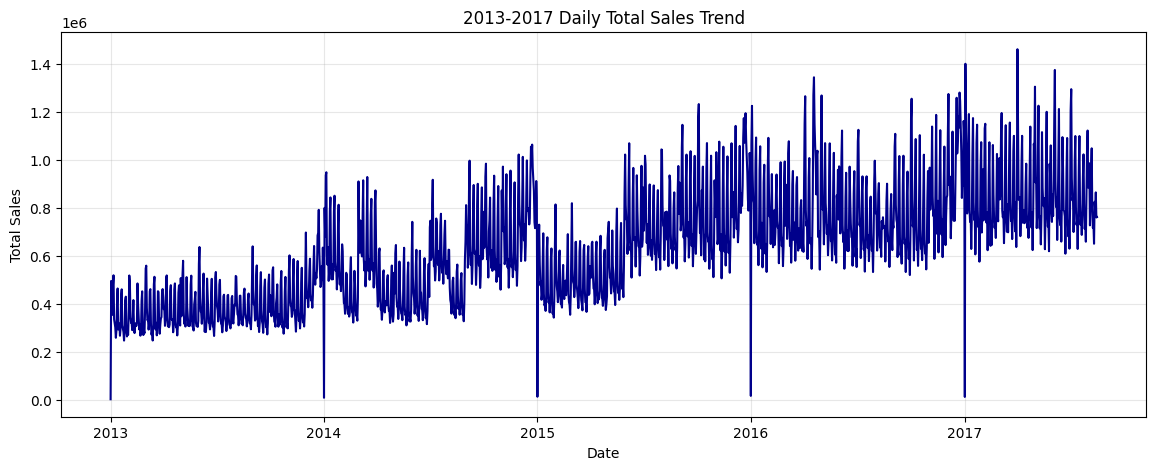

In [4]:
# Calculate total daily sales
daily_sales = train_raw.groupby('date')['sales'].sum().reset_index()

# Plot the daily sales trend
plt.figure(figsize=(14,5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='darkblue')

# Chart title and labels
plt.title('2013-2017 Daily Total Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')

# Add grid
plt.grid(alpha=0.3)

# Display the plot
plt.show()

1.2 Holiday vs Non-Holiday Sales Comparison (Illustrative Only – Exact Matching Will Be Done Later)

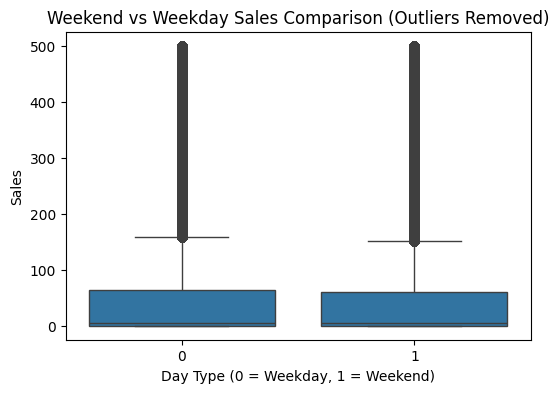

In [5]:
# Create a weekend indicator (1 = Weekend, 0 = Weekday)
train_raw['is_weekend'] = (train_raw['date'].dt.dayofweek >= 5).astype(int)

# Create the box plot
plt.figure(figsize=(6,4))
sns.boxplot(
    x='is_weekend',
    y='sales',
    data=train_raw[train_raw['sales'] < 500]  # Exclude extreme outliers for better visualization
)

# Add title and axis labels
plt.title('Weekend vs Weekday Sales Comparison (Outliers Removed)')
plt.xlabel('Day Type (0 = Weekday, 1 = Weekend)')
plt.ylabel('Sales')

# Display the plot
plt.show()

1.3 Relationship Between Oil Prices and Sales

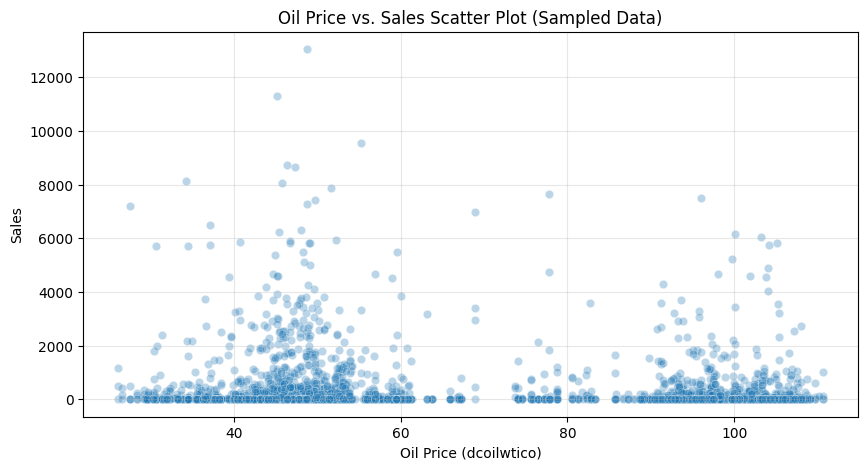

In [6]:
# Resample oil price data to daily frequency
oil_daily = oil_raw.set_index('date').resample('D').mean().reset_index()

# Merge sales data with daily oil prices
merged_oil = train_raw.merge(oil_daily, on='date', how='left')

# Create a scatter plot using a sample of 5,000 records
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='dcoilwtico',
    y='sales',
    data=merged_oil.sample(5000),
    alpha=0.3
)

# Add title and axis labels
plt.title('Oil Price vs. Sales Scatter Plot (Sampled Data)')
plt.xlabel('Oil Price (dcoilwtico)')
plt.ylabel('Sales')

# Add grid
plt.grid(alpha=0.3)

# Display the plot
plt.show()

Cell 3: Feature Engineering (Based on the Original Approach, with Minor Adjustments to Support the Validation Set)

In [7]:
print("Starting Feature Engineering...")

Starting Feature Engineering...


3.1 Data Filtering: Use Data from April 1, 2017 Onward

In [8]:
# Keep only records from April 1, 2017 onward for training
train = train_raw[train_raw['date'] >= '2017-04-01'].reset_index(drop=True)

# Create a copy of the test dataset
test = test_raw.copy()

3.2 Dead Product Identification (90 Consecutive Days of Zero Sales)

products that have had absolutely no sales for the last 90 consecutive days.

In [9]:
# Select data from the last 90 days
last_90_days = train[train['date'] >= '2017-05-16']

# Calculate the total sales for each store-product family combination
inactive_stats = last_90_days.groupby(['store_nbr', 'family'])['sales'].sum().reset_index()

# Identify combinations with zero total sales over the last 90 days
true_dead_keys = set(zip(
    inactive_stats[inactive_stats['sales'] == 0]['store_nbr'],
    inactive_stats[inactive_stats['sales'] == 0]['family']
))

# Display the number of inactive combinations
print(f"Identified {len(true_dead_keys)} store-family combinations with zero sales for 90 consecutive days.")

Identified 82 store-family combinations with zero sales for 90 consecutive days.


**Oil price and check external features**

In [10]:
oil = oil_raw.set_index('date').resample('D').mean().interpolate(limit_direction='both').reset_index()
#interpolate missing values,using the nearby values
#.reset_index() convert the data back into normal column
#step2:- create "oil price feature"
#7-days caluclate rolling average oil price
#this will helps the model to understand the overall oil price trend
oil['oil_roll_7'] = oil['dcoilwtico'].rolling(7,min_periods=1).mean()
oil['oil_fwd_1'] = oil['dcoilwtico'].shift(-1).fillna(method='ffill')
oil['oil_fwd_3'] = oil['dcoilwtico'].shift(-3).fillna(method='ffill')#oil price 3 days into future
oil['oil_roll_7'] = oil['dcoilwtico'].shift(-7).fillna(method='ffill')#oil price 7 days into future

#step 3:- merge external features
def merge_base(df):
  df = df.merge(stores,on='store_nbr',how = 'left')
  df = df.merge(oil,on = 'date',how = 'left')
  return df
train = merge_base(train)
test = merge_base(test)

In [11]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,is_weekend,city,state,store_type,cluster,dcoilwtico,oil_roll_7,oil_fwd_1,oil_fwd_3
0,2756754,2017-04-01,1,AUTOMOTIVE,9.0,0,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99
1,2756755,2017-04-01,1,BABY CARE,0.0,0,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99
2,2756756,2017-04-01,1,BEAUTY,1.0,0,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99
3,2756757,2017-04-01,1,BEVERAGES,3229.0,8,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99
4,2756758,2017-04-01,1,BOOKS,0.0,0,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99


In [12]:
holidays.head()

#remove transferred holidays
#we only keep holidays that are actually observed on their original data
#holiday that are moved to another date can be excluded
holidays = holidays[holidays['transferred']==False]
holidays

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [13]:
#create a function for the holiday indicator
def apply_holiday(df):
  df['is_holiday']=0
  for _,h in holidays.iterrows():
    if h['locale']=='National':
      df.loc[df['date']==h['date'],'is_holiday']=1
    elif h['locale']=='Regional':
      df.loc[(df['date']==h['date']) &(df['state']==h['locale_name']),'is_holiday']=1
    elif h['locale']=='Local':
      df.loc[(df['date']==h['date']) &(df['city']==h['locale_name']),'is_holiday']=1
  for _,wd in holidays[holidays['type']=='work day'].iterrows():
    df.loc[df['date']==wd['date'],'is_holiday']=0
  return df

#apply the function on train and test data
train = apply_holiday(train)
test = apply_holiday(test)

**3.5 Time-based(temporal) feature engineering**

In [14]:
#create use full features from "date"  column
#features created
#1.day --> day of the month,
#day of week
#is_weekend
#is_payday


def create_temporal_features(df):
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['isweekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_payday'] = ((df['day'] == 1) | (df['date'].dt.is_month_end)).astype(int)
    return df

train = create_temporal_features(train)
test = create_temporal_features(test)


In [15]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,is_weekend,city,state,store_type,cluster,dcoilwtico,oil_roll_7,oil_fwd_1,oil_fwd_3,is_holiday,day,dayofweek,isweekend,is_payday
0,2756754,2017-04-01,1,AUTOMOTIVE,9.0,0,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99,0,1,5,1,1
1,2756755,2017-04-01,1,BABY CARE,0.0,0,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99,0,1,5,1,1
2,2756756,2017-04-01,1,BEAUTY,1.0,0,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99,0,1,5,1,1
3,2756757,2017-04-01,1,BEVERAGES,3229.0,8,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99,0,1,5,1,1
4,2756758,2017-04-01,1,BOOKS,0.0,0,1,Quito,Pichincha,D,13,50.443333,52.52,50.346667,50.99,0,1,5,1,1


**3.6 combine train and test datasets create lag and rolling features**

In [16]:
df_all = pd.concat([train,test],ignore_index=True)
#sales from 21 days (3 weeks ago) --> lag features
df_all['sales_lag_21'] = df_all.groupby(['store_nbr','family'])['sales'].shift(21)
#sales from 28days means 4 weeks ago
#this will capture monthly and weekly recurring patterns
df_all['sales_lag_28'] = df_all.groupby(['store_nbr','family'])['sales'].shift(28)
#calculate the 7-days rolling average based on 21 days lagfeature
df_all['sales_roll_21_7'] = df_all.groupby(['store_nbr','family'])['sales_lag_21'].transform(
    lambda x:x.rolling(7,min_periods=1).mean()
)
#calculate the 3-days rolling average
df_all['promo_roll_3'] = df_all.groupby(['store_nbr','family'])['onpromotion'].transform(
    lambda x:x.rolling(3,min_periods=1).mean()
)
#combine dataset back into training and testing

train = df_all[df_all['date']<'2017-08-16'].dropna(subset=['sales_lag_28'])
#test set starts from agust 16,2017
test = df_all[df_all['date']>='2017-08-16']

**3.7 encode the categorical features**

In [17]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,is_weekend,city,state,store_type,...,oil_fwd_3,is_holiday,day,dayofweek,isweekend,is_payday,sales_lag_21,sales_lag_28,sales_roll_21_7,promo_roll_3
49896,2806650,2017-04-29,1,AUTOMOTIVE,2.0,0,1.0,Quito,Pichincha,D,...,47.65,0,29,5,1,0,8.0,9.0,7.142857,0.0
49897,2806651,2017-04-29,1,BABY CARE,0.0,0,1.0,Quito,Pichincha,D,...,47.65,0,29,5,1,0,0.0,0.0,0.000000,0.0
49898,2806652,2017-04-29,1,BEAUTY,5.0,0,1.0,Quito,Pichincha,D,...,47.65,0,29,5,1,0,2.0,1.0,2.428571,0.0
49899,2806653,2017-04-29,1,BEVERAGES,2156.0,33,1.0,Quito,Pichincha,D,...,47.65,0,29,5,1,0,2729.0,3229.0,2237.571429,31.0
49900,2806654,2017-04-29,1,BOOKS,0.0,0,1.0,Quito,Pichincha,D,...,47.65,0,29,5,1,0,0.0,0.0,0.571429,0.0


In [18]:
#list the categorical column
cats = ['family','city','state','store_type']
encoders = {}
for col in cats:
  le = LabelEncoder()
  #fit the encoders on tarin and test data
  #This ensures that no unseen categories appears in the test set
  all_vals = pd.concat([train[col],test[col]],axis=0).fillna("unknown")
  le.fit(all_vals)
  train[col]=le.transform(train[col])
  test[col]=le.transform(test[col])
  encoders[col] = le

In [19]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'is_weekend', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico',
       'oil_roll_7', 'oil_fwd_1', 'oil_fwd_3', 'is_holiday', 'day',
       'dayofweek', 'isweekend', 'is_payday', 'sales_lag_21', 'sales_lag_28',
       'sales_roll_21_7', 'promo_roll_3'],
      dtype='object')

In [20]:
features = ['store_nbr', 'family', 'onpromotion','is_weekend', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico',
            'oil_roll_7', 'oil_fwd_1', 'oil_fwd_3', 'is_holiday','day', 'dayofweek', 'isweekend', 'is_payday', 'sales_lag_21',
            'sales_lag_28', 'sales_roll_21_7', 'promo_roll_3']
cat_idx = ['family','city','state','store_type','cluster','store_nbr']

X_all = train[features]
y_all = np.log1p(train['sales'])

In [21]:
y_all

,sales
49896,1.098612
49897,0.000000
49898,1.791759
49899,7.676474
49900,0.000000
...,...
244129,6.084802
244130,5.046987
244131,7.791824
244132,4.804021


**3.9 split the data**

In [22]:
#for timeseries data we should not use random splitting of the data beacuse it can randomly choose past and the current data
#In the time series the data can be splitting in chronologically because avoid data leakage
#exam :- tarin data --> jan 2013 ---> july 31-2017
# test data :- july 31 2017 to aug 1-15,2017
#the model learns from the past data and evaluates from the future data
#so it prevents data lekage, some of the data picking randomly random date in test validation influence the training data
split_date = '2017-07-31'
#create mask data from train data
train_mask = train['date']<=split_date
val_mask = (train['date']>split_date) & (train['date']<'2017-08-16')

X_train = X_all[train_mask]
y_train = y_all[train_mask]
X_val = X_all[val_mask]
y_val = y_all[val_mask]
#display the size of training and validation data
print(f"train set size: {len(X_train)}, Validation set size: {len(X_val)}")

#training data = 167508    , test = 26730

train set size: 167508, Validation set size: 26730


4.1 LightGBM

In [23]:
m_lgb = lgb.LGBMRegressor(
    n_estimators=1000,learning_rate=0.01,num_leaves=63,
    random_state=42,n_jobs=-1
)
#n_jobs=-1 it uses all the cores to execute faster
m_lgb.fit(X_train,y_train,
          eval_set=[(X_train,y_train),(X_val,y_val)],
          callbacks=[lgb.early_stopping(50),lgb.log_evaluation(0)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1811
[LightGBM] [Info] Number of data points in the train set: 167508, number of used features: 21
[LightGBM] [Info] Start training from score 3.630703
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[507]	training's l2: 0.1675	valid_1's l2: 0.186112


LGBMRegressor(learning_rate=0.01, n_estimators=1000, n_jobs=-1, num_leaves=63,
              random_state=42)

4.2 XGBOOST

In [24]:
import xgboost as xgb
#create copies of training and validation and test features
#use the copy() so the original data remainsunchanghed
X_tr_x = X_train.copy()
X_val_x = X_val.copy()
X_te_x = test[features].copy()
#convert all the category to category
for c in cat_idx:
  X_tr_x[c] = X_tr_x[c].astype('category')
  X_val_x[c] = X_val_x[c].astype('category')
  X_te_x[c] = X_te_x[c].astype('category')

#apply the xgboost
m_xgb=xgb.XGBRegressor(
    n_estimators=800,learning_rate=0.04,max_depth=7,
    tree_method='hist',enable_categorical=True,
    random_state=42,n_jobs=-1
)

#fit the model
m_xgb.fit(
    X_tr_x,y_train,
    eval_set=[(X_val_x,y_val)],
    verbose = False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=-1, num_parallel_tree=None, ...)

5.Validation prediction and ensemble weight search

In [25]:
p_lgb_val = np.expm1(m_lgb.predict(X_val))
#np.expm1() : converts logscale predicition in to original values (np.log1p(train['sales]))
p_xgb_val = np.expm1(m_xgb.predict(X_val_x))

#find the error
def rmsle(y_true,y_pred):
  return np.sqrt(np.mean((np.log1p(y_true)-np.log1p(y_pred))**2))

#grid search for the best ensemble weights
best_score = 1e9     # this is scientific notation  1e9 = 1 * 10^9
best_w = None

for w1 in np.arange(0.1,0.7,0.05):
  w2 = 1 - w1
  #weighted ensemble prediction
  pred = (
      w1 * p_lgb_val +
      w2 * p_xgb_val
  )
 #calculate rmsle
  score = rmsle(y_val,pred)

 #update the best weights if the score improves
  if score < best_score:
    best_score = score
    best_w = [w1,w2]
print(
    f"best ensemble weights: "
    f"LightGBM={best_w[0]:.2f},"
    f"Xgboost={best_w[1]:.2f},"
    f"RMSLE={best_score:.4f}"
)

#generate the ensemble prediction on test dataset
p_lgb_test = np.expm1(m_lgb.predict(test[features])) #exmp1 are convert transform data into original
p_xgb_test = np.expm1(m_xgb.predict(X_te_x))
#compute the final ensemble predicitons

test['sales'] = (
    best_w[0]*p_lgb_test + best_w[1]*p_xgb_test
)

#ensure that sales prediciton are non- negative
test['sales'] = np.clip(test['sales'],0,None)

best ensemble weights: LightGBM=0.65,Xgboost=0.35,RMSLE=2.9833


In [26]:
test['sales']

,sales
244134,4.444109
244135,0.062517
244136,4.525624
244137,2161.753705
244138,0.045901
...,...
272641,341.190183
272642,101.135667
272643,1145.114040
272644,88.414492


In [27]:
X_val

,store_nbr,family,onpromotion,is_weekend,city,state,store_type,cluster,dcoilwtico,oil_roll_7,...,oil_fwd_3,is_holiday,day,dayofweek,isweekend,is_payday,sales_lag_21,sales_lag_28,sales_roll_21_7,promo_roll_3
217404,1,0,0,0.0,18,12,3,13,49.19,49.07,...,49.57,0,1,1,0,1,7.000,5.000,4.000000,0.000000
217405,1,1,0,0.0,18,12,3,13,49.19,49.07,...,49.57,0,1,1,0,1,0.000,0.000,0.000000,0.000000
217406,1,2,0,0.0,18,12,3,13,49.19,49.07,...,49.57,0,1,1,0,1,4.000,6.000,2.857143,0.000000
217407,1,3,26,0.0,18,12,3,13,49.19,49.07,...,49.57,0,1,1,0,1,2372.000,2284.000,2255.857143,22.000000
217408,1,4,0,0.0,18,12,3,13,49.19,49.07,...,49.57,0,1,1,0,1,1.000,0.000,0.285714,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244129,9,28,0,0.0,18,12,1,6,47.57,47.65,...,48.59,0,15,1,0,0,320.009,320.401,392.798569,0.000000
244130,9,29,1,0.0,18,12,1,6,47.57,47.65,...,48.59,0,15,1,0,0,51.879,118.927,86.165143,0.666667
244131,9,30,148,0.0,18,12,1,6,47.57,47.65,...,48.59,0,15,1,0,0,2100.046,2178.149,1565.428143,54.000000
244132,9,31,8,0.0,18,12,1,6,47.57,47.65,...,48.59,0,15,1,0,0,5.000,0.000,1.857143,9.000000


In [28]:
# 1. Correct the RMSLE calculation scale
y_val_true = np.expm1(y_val)

def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

best_score = 1e9
best_w = None

for w1 in np.arange(0.1, 0.7, 0.05):
    w2 = 1 - w1
    pred = w1 * p_lgb_val + w2 * p_xgb_val
    score = rmsle(y_val_true, pred)
    if score < best_score:
        best_score = score
        best_w = [w1, w2]

print(f"Corrected Validation RMSLE: {best_score:.4f} (LGBM: {best_w[0]:.2f}, XGB: {best_w[1]:.2f})")

# 2. Extract and export the submission file
submission = test[['id', 'sales']].copy()
submission.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully. Shape:", submission.shape)

Corrected Validation RMSLE: 0.4127 (LGBM: 0.15, XGB: 0.85)
Saved submission.csv successfully. Shape: (28512, 2)


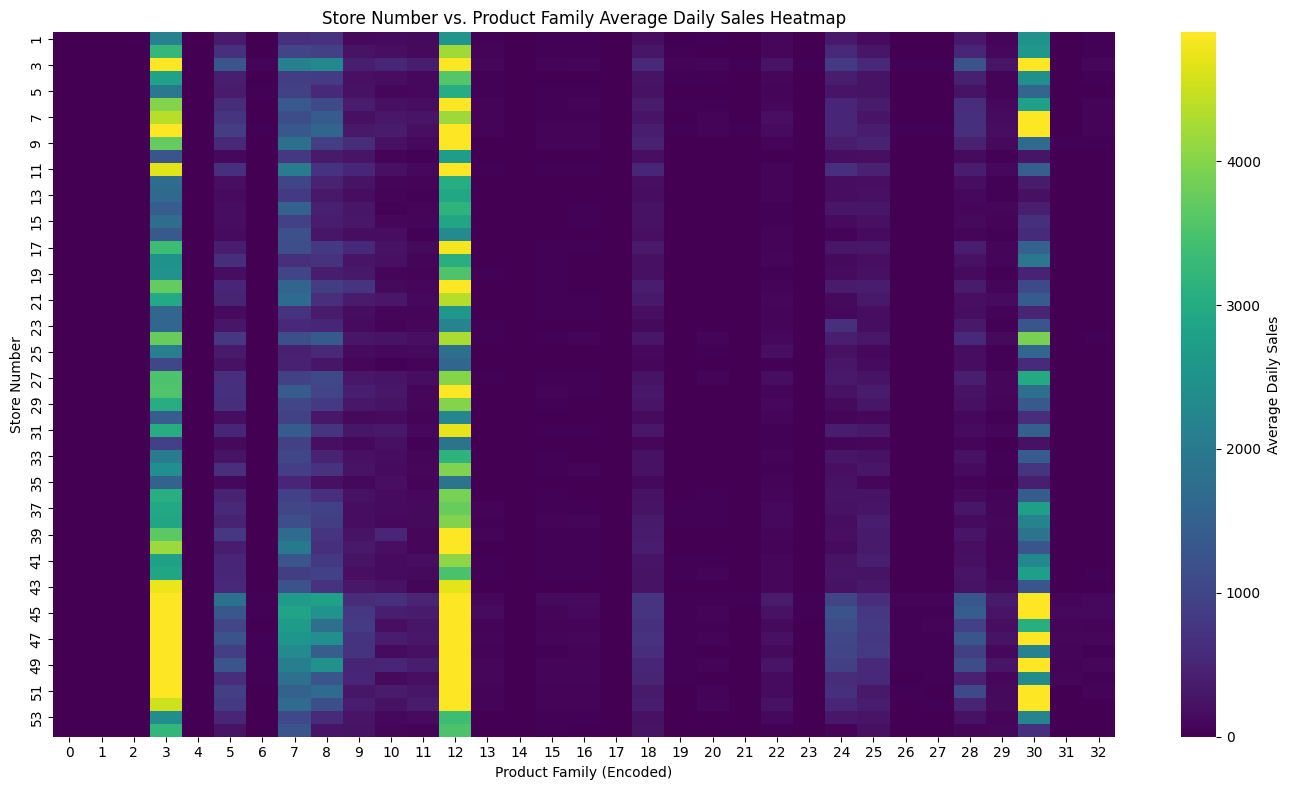

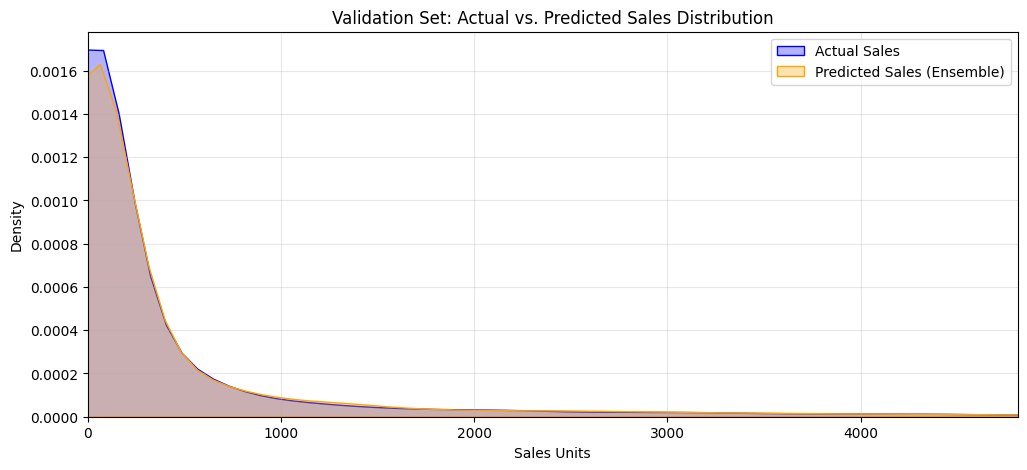

In [29]:
# 6.1 Matrix of Store vs. Product Family Sales Dynamics
pivot_sales = train.groupby(['store_nbr', 'family'])['sales'].mean().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_sales, cmap='viridis', robust=True, cbar_kws={'label': 'Average Daily Sales'})
plt.title('Store Number vs. Product Family Average Daily Sales Heatmap')
plt.xlabel('Product Family (Encoded)')
plt.ylabel('Store Number')
plt.tight_layout()
plt.show()

# 6.2 Actual vs. Predicted Sales Distribution on Validation Set
final_val_pred = 0.15 * p_lgb_val + 0.85 * p_xgb_val

plt.figure(figsize=(12, 5))
sns.kdeplot(y_val_true, label='Actual Sales', color='blue', fill=True, alpha=0.3)
sns.kdeplot(final_val_pred, label='Predicted Sales (Ensemble)', color='orange', fill=True, alpha=0.3)
plt.title('Validation Set: Actual vs. Predicted Sales Distribution')
plt.xlabel('Sales Units')
plt.ylabel('Density')
plt.xlim(0, np.percentile(y_val_true, 98))  # Exclude extreme outliers for clear visualization
plt.legend()
plt.grid(alpha=0.3)
plt.show()

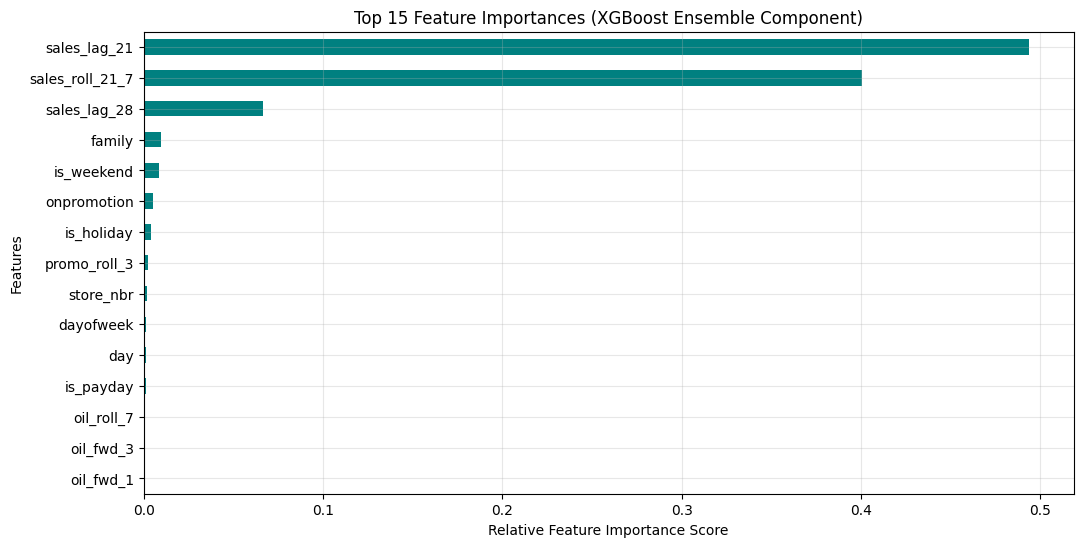

In [30]:
# 7. Feature Importance Analysis
plt.figure(figsize=(12, 6))
xgb_importance = pd.Series(m_xgb.feature_importances_, index=features).sort_values(ascending=True)
xgb_importance.tail(15).plot(kind='barh', color='teal')

plt.title('Top 15 Feature Importances (XGBoost Ensemble Component)')
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Features')
plt.grid(alpha=0.3)
plt.show()

**6.Visualization diognastics**


* check combination of features




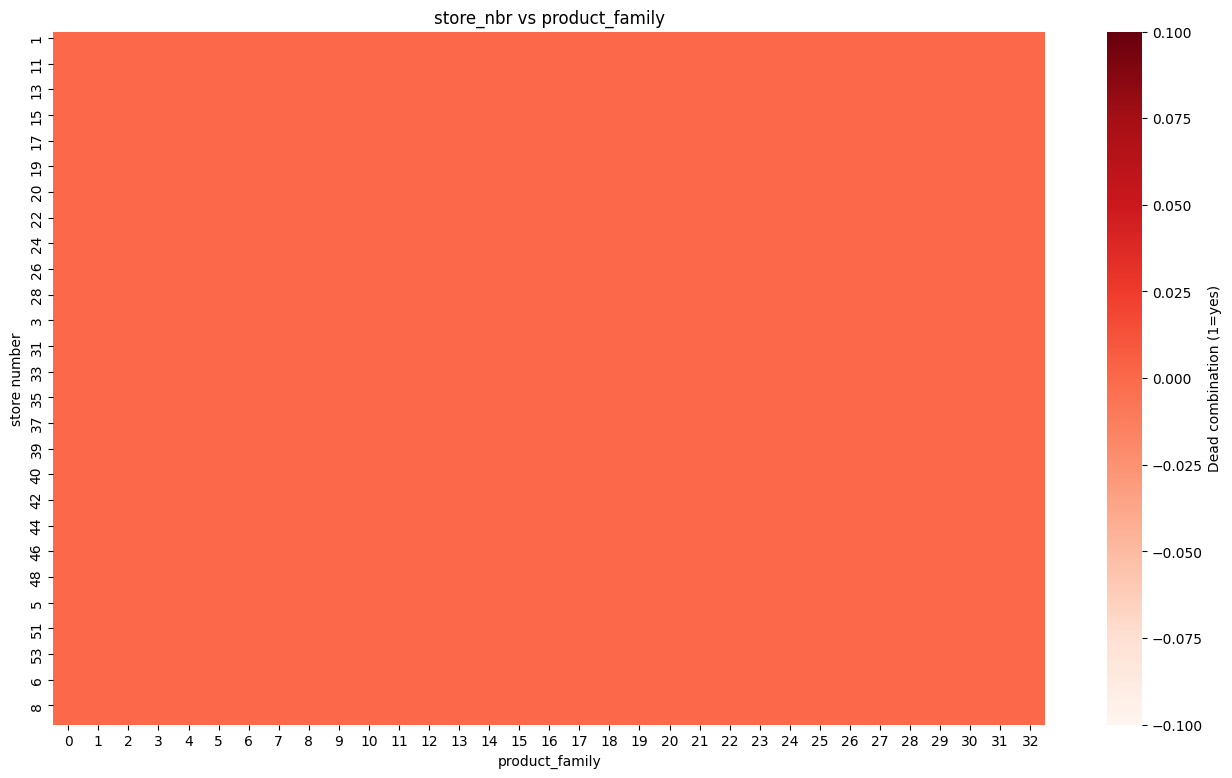

In [31]:
#create a empty matrix
#rows represents the store number
#columns represents the product families

dead_matrix = pd.DataFrame(
    0,
    index=test['store_nbr'].unique(),
    columns = test['family'].unique()
)

for (store,family) in true_dead_keys:
  if store in dead_matrix.index and family in dead_matrix.columns:
    dead_matrix.loc[store,family] = 1

#creat a heatmap
plt.figure(figsize=(16,9))
sns.heatmap(dead_matrix,cmap='Reds',cbar_kws={'label':'Dead combination (1=yes)'})
plt.title("store_nbr vs product_family")
plt.xlabel('product_family')
plt.ylabel('store number')
plt.show()

**6.2 Lgbm feature importance**

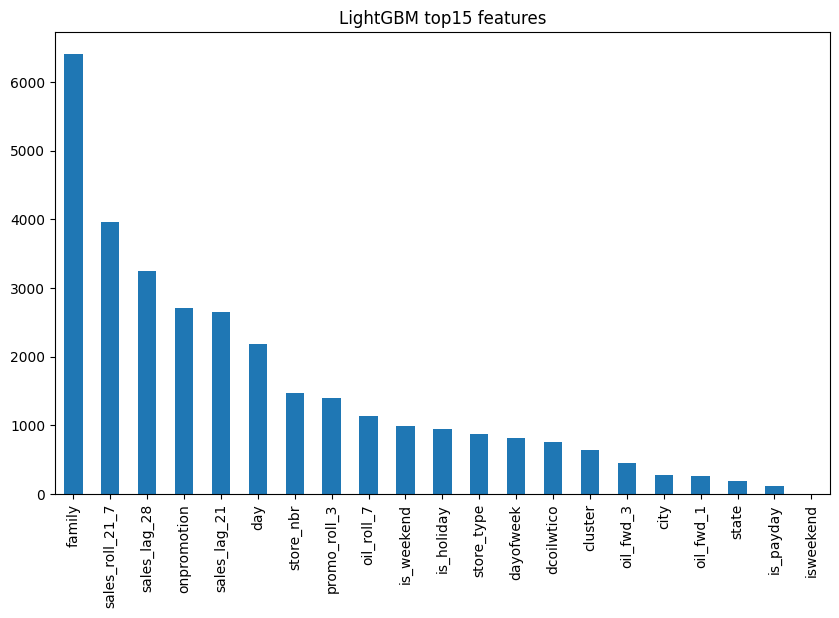

In [32]:
importance = m_lgb.feature_importances_
feat_imp = pd.Series(importance,index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(25).plot(kind='bar')
plt.title("LightGBM top15 features")
plt.show()

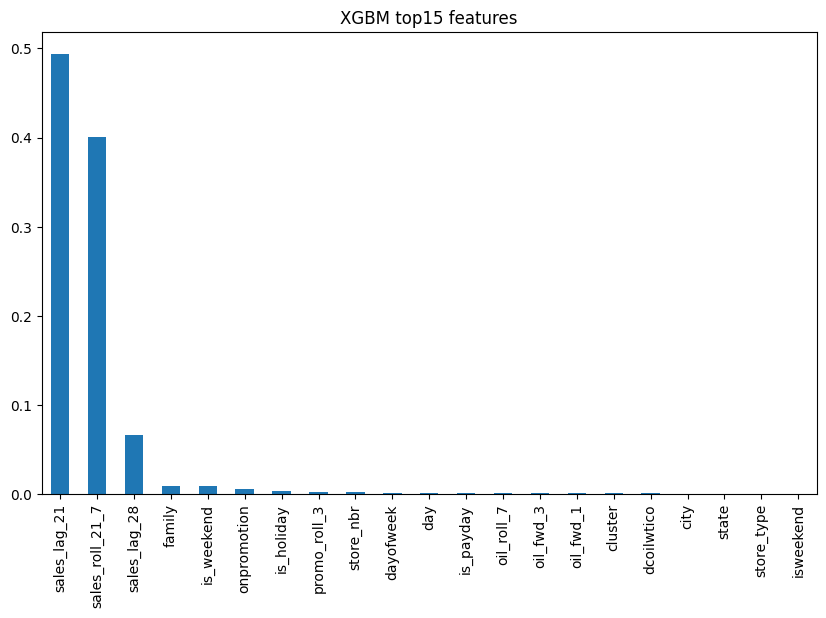

In [33]:
importence = m_xgb.feature_importances_
feat_imp = pd.Series(importence,index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(25).plot(kind='bar')
plt.title("XGBM top15 features")
plt.show()

**7 submission of file generation**

In [34]:
print("Applying the safe post processing rules ")
def apply_rules(row):
  if (row['store_nbr'],row['family']) in true_dead_keys:
    return 0.0
  return row['sales']

#apply the rules to every row of the slaes data
test['sales'] = test.apply(apply_rules,axis=1)

submission = pd.DataFrame({
    "id":test['id'].astype('int'),
    'sales':test['sales']
})


submission.to_csv("submission.csv",index=False)
print("submission file has been created successfully")


Applying the safe post processing rules 
submission file has been created successfully


**Model Evaluation**

In [35]:
#check the evaluation metrics and convert to pickle file to build the ai model
#find the MAE,MSE,R2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

**ensemble predictions**

In [36]:
pred_val = (
    best_w[0]*p_lgb_val+
    best_w[1]*p_xgb_val
)
pred

array([3.78004445e+00, 4.96714860e-02, 3.06101371e+00, ...,
       2.05768838e+03, 5.22633622e+01, 1.17151258e+01])

**MAE**

In [37]:

mae = mean_absolute_error(y_val,pred_val)
mae

485.117174104764

**MSE**

In [38]:
mse = mean_squared_error(y_val,pred_val)
mse

1999438.4743950951

**RMSE**

In [39]:
rmse = np.sqrt(mean_squared_error(y_val,pred_val))
rmse

np.float64(1414.01501915471)

**R2_Score**

In [40]:
r2 = r2_score(y_val,pred_val)
r2

-314414.41759778926

In [41]:
y_val_original = np.expm1(y_val)

In [42]:
y_val_original[:10]

,sales
217404,5.00000
217405,0.00000
217406,4.00000
217407,2627.00000
217408,0.00000
217409,373.70898
217410,11.00000
217411,867.00000
217412,668.00000
217413,133.58800


In [43]:
r2 = r2_score(y_val_original,pred_val)
r2

0.9554207632355913

In [44]:
mae = mean_absolute_error(y_val_original,pred_val)
mae

76.27718962050025

In [45]:
rmse = np.sqrt(mean_squared_error(y_val_original,pred_val))
rmse

np.float64(262.71554629326914)

In [46]:
mse = mean_squared_error(y_val_original,pred_val)
mse

69019.45826417084

**Save the evaluation metrics**

In [47]:
metrics = {
    "MAE":mae,
    "RMSLE":rmsle,
    "r2_score":r2
}

**convert the metrics to pickle file**

In [48]:
import pickle
pickle.dump(metrics,open("metrics.pkl","wb"))

**Save the model to pickle file**

In [49]:
with open("lightgbm_model.pkl","wb") as file:
  pickle.dump(m_xgb,file)
print("lightgbm model is saved successfully")

lightgbm model is saved successfully


In [50]:
#save xgboost model
with open("xgboost_model.pkl","wb") as file:
  pickle.dump(m_xgb,file)
print("xgboost model is saved successfully ")

xgboost model is saved successfully 


In [51]:
#save the best ensemble weights
best_w

[np.float64(0.15000000000000002), np.float64(0.85)]

In [52]:
with open("ensemble_weight.pkl","wb") as file:
  pickle.dump(best_w,file)
print("ensemble_weights are saved successfully")

ensemble_weights are saved successfully


In [53]:
#save label encoding
encoders

{'family': LabelEncoder(),
 'city': LabelEncoder(),
 'state': LabelEncoder(),
 'store_type': LabelEncoder()}

In [54]:
with open("label_encoders.pkl","wb") as file:
  pickle.dump(encoders,file)
print("label_encoders are saved successfully")

label_encoders are saved successfully


In [55]:
#save features in pkl format
with open("features_columns.pkl","wb") as file:
  pickle.dump(features,file)
print(" features_columns are saved successfully")

 features_columns are saved successfully


In [56]:
print(features)

['store_nbr', 'family', 'onpromotion', 'is_weekend', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'oil_roll_7', 'oil_fwd_1', 'oil_fwd_3', 'is_holiday', 'day', 'dayofweek', 'isweekend', 'is_payday', 'sales_lag_21', 'sales_lag_28', 'sales_roll_21_7', 'promo_roll_3']


In [57]:
X_all[features]

,store_nbr,family,onpromotion,is_weekend,city,state,store_type,cluster,dcoilwtico,oil_roll_7,...,oil_fwd_3,is_holiday,day,dayofweek,isweekend,is_payday,sales_lag_21,sales_lag_28,sales_roll_21_7,promo_roll_3
49896,1,0,0,1.0,18,12,3,13,49.15,46.306667,...,47.65,0,29,5,1,0,8.000,9.000,7.142857,0.000000
49897,1,1,0,1.0,18,12,3,13,49.15,46.306667,...,47.65,0,29,5,1,0,0.000,0.000,0.000000,0.000000
49898,1,2,0,1.0,18,12,3,13,49.15,46.306667,...,47.65,0,29,5,1,0,2.000,1.000,2.428571,0.000000
49899,1,3,33,1.0,18,12,3,13,49.15,46.306667,...,47.65,0,29,5,1,0,2729.000,3229.000,2237.571429,31.000000
49900,1,4,0,1.0,18,12,3,13,49.15,46.306667,...,47.65,0,29,5,1,0,0.000,0.000,0.571429,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244129,9,28,0,0.0,18,12,1,6,47.57,47.650000,...,48.59,0,15,1,0,0,320.009,320.401,392.798569,0.000000
244130,9,29,1,0.0,18,12,1,6,47.57,47.650000,...,48.59,0,15,1,0,0,51.879,118.927,86.165143,0.666667
244131,9,30,148,0.0,18,12,1,6,47.57,47.650000,...,48.59,0,15,1,0,0,2100.046,2178.149,1565.428143,54.000000
244132,9,31,8,0.0,18,12,1,6,47.57,47.650000,...,48.59,0,15,1,0,0,5.000,0.000,1.857143,9.000000


In [58]:
X_all["family"]

,family
49896,0
49897,1
49898,2
49899,3
49900,4
...,...
244129,28
244130,29
244131,30
244132,31


In [59]:
X_all["onpromotion"]

,onpromotion
49896,0
49897,0
49898,0
49899,33
49900,0
...,...
244129,0
244130,1
244131,148
244132,8


In [60]:
X_all['store_type']

,store_type
49896,3
49897,3
49898,3
49899,3
49900,3
...,...
244129,1
244130,1
244131,1
244132,1


In [61]:
X_all["cluster"]

,cluster
49896,13
49897,13
49898,13
49899,13
49900,13
...,...
244129,6
244130,6
244131,6
244132,6


In [62]:
X_all["is_weekend"]

,is_weekend
49896,1.0
49897,1.0
49898,1.0
49899,1.0
49900,1.0
...,...
244129,0.0
244130,0.0
244131,0.0
244132,0.0


In [63]:
X_all['dcoilwtico']

,dcoilwtico
49896,49.15
49897,49.15
49898,49.15
49899,49.15
49900,49.15
...,...
244129,47.57
244130,47.57
244131,47.57
244132,47.57
